# 🛡️ Real-Time Weapon Detection System (YOLO11s)
### Advanced Computer Vision for Threat Identification & False Alarm Reduction

**Project Overview:**
This notebook implements an end-to-end deep learning pipeline for real-time weapon detection using the state-of-the-art **YOLO11s** architecture. To minimize false positives and security alarm fatigue, the system distinguishes between **real lethal weapons** (handguns, knives, firearms) and **toy/replica weapons**.

---
### 📊 Key Project Specifications:
- **Architecture:** Ultralytics YOLO11s (9.4 Million Parameters)
- **Primary Classes:**
  - `0: real_weapon` (Real pistols, revolvers, knives, rifles)
  - `1: toy_weapon` (Toy guns, nerf blasters, plastic replicas)
- **Hard Negative Mining:** Background environments and common handheld objects to suppress false alarms
- **Input Resolution:** 640 × 640
- **Training Strategy:** 100-Epoch AdamW Baseline Training + 25-Epoch Low-LR Fine-Tuning
- **Achieved Metrics:** **90.8% mAP@50**, **90.9% Precision**, **85.2% Recall**


---
## 1. Environment Configuration & Setup
Mount Google Drive, install the required deep learning dependencies (Ultralytics, OpenCV, PyYAML), and verify GPU acceleration.


In [ ]:
# Mount Google Drive for persistent storage
from google.colab import drive
drive.mount('/content/drive')

# Install Ultralytics and dependencies
!pip install -q ultralytics roboflow pyyaml

import os
import torch
import ultralytics
print("=" * 60)
print(f"PyTorch Version:     {torch.__version__}")
print(f"Ultralytics Version: {ultralytics.__version__}")
print(f"CUDA Available:      {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device:          {torch.cuda.get_device_name(0)}")
print("=" * 60)


---
## 2. Dataset Ingestion & Directory Setup
Download and extract the initial weapon datasets from Kaggle:
- **Source 1:** Sohas Weapon Detection Dataset (VOC XML Format)
- **Source 2:** Gun Detection Dataset (CSV Format)


In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle API configured successfully!")

Kaggle API configured successfully!


In [ ]:
!mkdir -p /content/datasets/weapon_detection

!kaggle datasets download \
    -d ankan1998/weapon-detection-dataset \
    -p /content/datasets/weapon_detection \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/ankan1998/weapon-detection-dataset
License(s): unknown
100% 487M/487M [00:13<00:00, 37.1MB/s]



In [ ]:
import os
from glob import glob

base_path = "/content/datasets/weapon_detection/Sohas_weapon-Detection"

# Count images
train_images = glob(os.path.join(base_path, "images", "*"))
test_images = glob(os.path.join(base_path, "images_test", "*"))

# Count XML annotations
train_xml = glob(os.path.join(base_path, "annotations", "xmls", "*.xml"))
test_xml = glob(os.path.join(base_path, "annotations_test", "xmls", "*.xml"))

print("========== DATASET SUMMARY ==========")
print(f"Training images     : {len(train_images)}")
print(f"Training annotations: {len(train_xml)}")
print(f"Test images         : {len(test_images)}")
print(f"Test annotations    : {len(test_xml)}")

print("\n========== SAMPLE IMAGES ==========")
print([os.path.basename(x) for x in train_images[:10]])

print("\n========== SAMPLE XML FILES ==========")
print([os.path.basename(x) for x in train_xml[:10]])

========== DATASET SUMMARY ==========
Training images     : 1000
Training annotations: 1000
Test images         : 472
Test annotations    : 866

========== SAMPLE IMAGES ==========
['KravMagaTraining20585.jpg', 'billete_0206.jpg', 'MBmframe00373.jpg', 'DSC_0050.jpg', 'KravMagaTraining20825.jpg', 'DefenseKnifeAttack0809.jpg', 'LBmframe00349.jpg', 'KravMagaTraining566.jpg', 'KravMagaTraining21025.jpg', 'KravMagaKnifeDefenseTechniques762.jpg']

========== SAMPLE XML FILES ==========
['billete_0159.xml', 'MBmframe00157.xml', 'DSC_0032.xml', 'ABsframe00214.xml', 'billete_2043.xml', 'DefenseKnifeAttack0426.xml', 'billete_0160.xml', 'DSC_0001.xml', 'HBmframe00241.xml', 'KravMagaKnifeDefenseTechniques676.xml']


---
## 3. Annotation Standardization & Label Conversion
Convert Pascal VOC XML bounding boxes and CSV annotations into the normalized YOLO format `[class_id, x_center, y_center, width, height]`.


In [ ]:
import os
import shutil
import xml.etree.ElementTree as ET
from PIL import Image

# ==============================
# PATHS
# ==============================

source_base = "/content/datasets/weapon_detection/Sohas_weapon-Detection"

train_images_src = os.path.join(source_base, "images")
train_xml_src = os.path.join(source_base, "annotations", "xmls")

test_images_src = os.path.join(source_base, "images_test")
test_xml_src = os.path.join(source_base, "annotations_test", "xmls")

output_base = "/content/final_dataset"

os.makedirs(output_base, exist_ok=True)

print("Output directory:", output_base)


# ==============================
# CREATE TEMPORARY DIRECTORIES
# ==============================

os.makedirs(f"{output_base}/images_source1", exist_ok=True)
os.makedirs(f"{output_base}/labels_source1", exist_ok=True)


# ==============================
# CONVERT XML → YOLO
# ==============================

def convert_xml_to_yolo(xml_path, image_path, label_path):

    tree = ET.parse(xml_path)
    root = tree.getroot()

    # Get image dimensions
    img = Image.open(image_path)
    img_width, img_height = img.size

    yolo_lines = []

    for obj in root.findall("object"):

        class_name = obj.find("name").text.strip()

        # Keep ONLY knife
        if class_name != "knife":
            continue

        bbox = obj.find("bndbox")

        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        # YOLO center coordinates
        x_center = ((xmin + xmax) / 2) / img_width
        y_center = ((ymin + ymax) / 2) / img_height

        # YOLO width and height
        width = (xmax - xmin) / img_width
        height = (ymax - ymin) / img_height

        # Class 0 = real_weapon
        yolo_lines.append(
            f"0 {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"
        )

    # Write label file
    with open(label_path, "w") as f:
        f.write("\n".join(yolo_lines))


# ==============================
# PROCESS TRAIN + TEST IMAGES
# ==============================

all_image_dirs = [
    (train_images_src, train_xml_src),
    (test_images_src, test_xml_src)
]

total_images = 0
total_objects = 0

for image_dir, xml_dir in all_image_dirs:

    for image_name in os.listdir(image_dir):

        if not image_name.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            continue

        image_path = os.path.join(image_dir, image_name)

        xml_name = os.path.splitext(image_name)[0] + ".xml"
        xml_path = os.path.join(xml_dir, xml_name)

        # Some images may not have XML
        if not os.path.exists(xml_path):
            continue

        output_image = os.path.join(
            f"{output_base}/images_source1",
            image_name
        )

        output_label = os.path.join(
            f"{output_base}/labels_source1",
            os.path.splitext(image_name)[0] + ".txt"
        )

        # Copy image
        shutil.copy2(image_path, output_image)

        # Convert annotation
        convert_xml_to_yolo(
            xml_path,
            image_path,
            output_label
        )

        # Count objects
        with open(output_label) as f:
            lines = [x for x in f.read().splitlines() if x.strip()]

        total_objects += len(lines)
        total_images += 1

print("\n========== CONVERSION COMPLETE ==========")
print("Images converted:", total_images)
print("Weapon objects:", total_objects)

Output directory: /content/final_dataset

========== CONVERSION COMPLETE ==========
Images converted: 1472
Weapon objects: 1035


In [ ]:
!mkdir -p /content/datasets/gun_detection

!kaggle datasets download \
    -d abhishek4273/gun-detection-dataset \
    -p /content/datasets/gun_detection \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/abhishek4273/gun-detection-dataset
License(s): unknown
100% 239M/239M [00:07<00:00, 33.5MB/s]



In [ ]:
import os
import shutil
import pandas as pd
from PIL import Image

# ==============================
# PATHS
# ==============================

source_images = "/content/datasets/gun_detection/weapons/Images"
csv_path = "/content/datasets/gun_detection/weapons/train_labels.csv"

output_base = "/content/final_dataset"

os.makedirs(f"{output_base}/images_source2", exist_ok=True)
os.makedirs(f"{output_base}/labels_source2", exist_ok=True)


# ==============================
# READ CSV
# ==============================

df = pd.read_csv(csv_path)

total_objects = 0
processed_images = 0


# ==============================
# PROCESS EACH ROW
# ==============================

for _, row in df.iterrows():

    image_name = str(row["ID"])
    label_string = str(row["Label"])

    image_path = os.path.join(source_images, image_name)

    if not os.path.exists(image_path):
        continue

    # Read image dimensions
    img = Image.open(image_path)
    img_width, img_height = img.size

    # Example:
    # 400 243 788 403 pistol

    parts = label_string.split()

    xmin = float(parts[0])
    ymin = float(parts[1])
    xmax = float(parts[2])
    ymax = float(parts[3])

    class_name = " ".join(parts[4:])

    # We expect pistol
    if class_name.lower() != "pistol":
        continue

    # Convert to YOLO format
    x_center = ((xmin + xmax) / 2) / img_width
    y_center = ((ymin + ymax) / 2) / img_height

    width = (xmax - xmin) / img_width
    height = (ymax - ymin) / img_height

    # Class 0 = real_weapon
    yolo_line = (
        f"0 {x_center:.6f} {y_center:.6f} "
        f"{width:.6f} {height:.6f}"
    )

    # Copy image
    shutil.copy2(
        image_path,
        os.path.join(
            f"{output_base}/images_source2",
            image_name
        )
    )

    # Create label
    label_name = os.path.splitext(image_name)[0] + ".txt"

    with open(
        os.path.join(
            f"{output_base}/labels_source2",
            label_name
        ),
        "w"
    ) as f:
        f.write(yolo_line)

    processed_images += 1
    total_objects += 1


print("\n========== DATASET 2 CONVERSION ==========")
print("Images converted:", processed_images)
print("Weapon objects:", total_objects)


========== DATASET 2 CONVERSION ==========
Images converted: 2765
Weapon objects: 2765


In [ ]:
import os
import shutil

# ==============================
# SOURCE DIRECTORIES
# ==============================

source1_images = "/content/final_dataset/images_source1"
source1_labels = "/content/final_dataset/labels_source1"

source2_images = "/content/final_dataset/images_source2"
source2_labels = "/content/final_dataset/labels_source2"

# ==============================
# FINAL MERGED DIRECTORIES
# ==============================

final_images = "/content/final_dataset/images"
final_labels = "/content/final_dataset/labels"

os.makedirs(final_images, exist_ok=True)
os.makedirs(final_labels, exist_ok=True)


# ==============================
# COPY DATASET 1
# ==============================

count1 = 0

for image_name in os.listdir(source1_images):

    if not image_name.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    old_image = os.path.join(source1_images, image_name)
    old_label = os.path.join(
        source1_labels,
        os.path.splitext(image_name)[0] + ".txt"
    )

    # Add S1 prefix to avoid filename collision
    new_name = "S1_" + image_name
    new_label_name = os.path.splitext(new_name)[0] + ".txt"

    shutil.copy2(
        old_image,
        os.path.join(final_images, new_name)
    )

    if os.path.exists(old_label):

        shutil.copy2(
            old_label,
            os.path.join(final_labels, new_label_name)
        )

    count1 += 1


# ==============================
# COPY DATASET 2
# ==============================

count2 = 0

for image_name in os.listdir(source2_images):

    if not image_name.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    old_image = os.path.join(source2_images, image_name)
    old_label = os.path.join(
        source2_labels,
        os.path.splitext(image_name)[0] + ".txt"
    )

    # Add S2 prefix
    new_name = "S2_" + image_name
    new_label_name = os.path.splitext(new_name)[0] + ".txt"

    shutil.copy2(
        old_image,
        os.path.join(final_images, new_name)
    )

    if os.path.exists(old_label):

        shutil.copy2(
            old_label,
            os.path.join(final_labels, new_label_name)
        )

    count2 += 1


print("========== MERGE COMPLETE ==========")
print("Dataset 1 images:", count1)
print("Dataset 2 images:", count2)
print("Total images:", count1 + count2)

print("\nFinal images:", len(os.listdir(final_images)))
print("Final labels:", len(os.listdir(final_labels)))

========== MERGE COMPLETE ==========
Dataset 1 images: 1472
Dataset 2 images: 2765
Total images: 4237

Final images: 4237
Final labels: 4237


In [ ]:
import os

labels_dir = "/content/final_dataset/labels"

total_labels = 0
empty_labels = 0
weapon_labels = 0

for file in os.listdir(labels_dir):

    if not file.endswith(".txt"):
        continue

    total_labels += 1

    path = os.path.join(labels_dir, file)

    with open(path) as f:
        content = f.read().strip()

    if content == "":
        empty_labels += 1
    else:
        weapon_labels += len(content.splitlines())

print("========== LABEL SUMMARY ==========")
print("Total label files:", total_labels)
print("Empty label files:", empty_labels)
print("Weapon bounding boxes:", weapon_labels)

========== LABEL SUMMARY ==========
Total label files: 4237
Empty label files: 453
Weapon bounding boxes: 3800


---
## 4. Hard Negative Mining & Toy Weapon Integration
To eliminate false alarms (e.g. phones, wallets, harmless objects mistaken for weapons), we incorporate:
1. **Toy Weapon Dataset:** Authentic toy guns and replicas labeled as `class 1: toy_weapon`.
2. **Representation Hard Negatives:** Clean background images with empty label files so the model learns not to detect non-weapon handheld items.


In [ ]:
import zipfile
import os
import glob

zip_files = glob.glob("/content/*.zip")

if len(zip_files) == 0:
    raise FileNotFoundError("No ZIP file found in /content")

ZIP_PATH = zip_files[0]

EXTRACT_DIR = "/content/toy_dataset_raw"

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extracted:", ZIP_PATH)
print("Location:", EXTRACT_DIR)

Extracted: /content/toy-gun-dataset.v1-yolo.yolov8.zip
Location: /content/toy_dataset_raw


In [ ]:
import os
import shutil

OUTPUT_IMG = "/content/hard_negatives/toy_weapon/images"
OUTPUT_LBL = "/content/hard_negatives/toy_weapon/labels"

os.makedirs(OUTPUT_IMG, exist_ok=True)
os.makedirs(OUTPUT_LBL, exist_ok=True)

converted = 0
skipped = 0

for img_path in toy_images:

    base_name = os.path.splitext(os.path.basename(img_path))[0]

    # Find corresponding label
    possible_labels = glob.glob(
        f"/content/toy_dataset_raw/**/{base_name}.txt",
        recursive=True
    )

    if not possible_labels:
        skipped += 1
        continue

    label_path = possible_labels[0]

    # Read labels
    new_lines = []

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:

        parts = line.strip().split()

        if len(parts) != 5:
            continue

        # Change source class to our toy_weapon class
        parts[0] = "1"

        new_lines.append(" ".join(parts))

    # Unique filename
    new_name = f"TOY_{converted:05d}"

    ext = os.path.splitext(img_path)[1]

    new_img_path = os.path.join(
        OUTPUT_IMG,
        new_name + ext
    )

    new_label_path = os.path.join(
        OUTPUT_LBL,
        new_name + ".txt"
    )

    shutil.copy2(img_path, new_img_path)

    with open(new_label_path, "w") as f:
        f.write("\n".join(new_lines))

    converted += 1

print("Toy images converted:", converted)
print("Skipped:", skipped)

Toy images converted: 1451
Skipped: 0


In [ ]:
toy_final_images = os.listdir(
    "/content/hard_negatives/toy_weapon/images"
)

toy_final_labels = os.listdir(
    "/content/hard_negatives/toy_weapon/labels"
)

print("Toy images:", len(toy_final_images))
print("Toy labels:", len(toy_final_labels))

Toy images: 1451
Toy labels: 1451


In [ ]:
REP_DIR = "/content/hard_negatives/representation"

os.makedirs(f"{REP_DIR}/images", exist_ok=True)
os.makedirs(f"{REP_DIR}/labels", exist_ok=True)

print("Representation folders ready.")

Representation folders ready.


In [ ]:
# CELL 34 — Robust representation image downloader

import requests
import os
import time
from PIL import Image
from io import BytesIO

API_URL = "https://commons.wikimedia.org/w/api.php"

REP_IMG_DIR = "/content/hard_negatives/representation/images"
REP_LBL_DIR = "/content/hard_negatives/representation/labels"

os.makedirs(REP_IMG_DIR, exist_ok=True)
os.makedirs(REP_LBL_DIR, exist_ok=True)

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Colab Weapon Detection Student Project)"
}

search_terms = [
    "gun drawing",
    "pistol drawing",
    "rifle drawing",
    "gun illustration",
    "pistol illustration",
    "rifle illustration",
    "gun diagram",
    "pistol diagram",
    "rifle diagram",
    "gun poster",
    "weapon poster"
]

TARGET = 300

downloaded = 0
seen_urls = set()

for query in search_terms:

    if downloaded >= TARGET:
        break

    print("\nSearching:", query)

    params = {
        "action": "query",
        "format": "json",
        "generator": "search",
        "gsrsearch": query,
        "gsrnamespace": 6,
        "gsrlimit": 50,
        "prop": "imageinfo",
        "iiprop": "url|mime|size",
        "iiurlwidth": 800
    }

    try:
        response = requests.get(
            API_URL,
            params=params,
            headers=HEADERS,
            timeout=30
        )

        print("HTTP status:", response.status_code)

        # Check whether response is actually JSON
        if not response.text.strip():
            print("Empty response. Skipping...")
            continue

        if response.status_code != 200:
            print("Server response:", response.text[:200])
            continue

        try:
            data = response.json()
        except Exception:
            print("Response was not JSON:")
            print(response.text[:300])
            continue

    except Exception as e:
        print("Request error:", e)
        continue

    pages = data.get("query", {}).get("pages", {})

    for page in pages.values():

        if downloaded >= TARGET:
            break

        imageinfo = page.get("imageinfo", [])

        if not imageinfo:
            continue

        info = imageinfo[0]

        image_url = info.get("thumburl") or info.get("url")
        mime = info.get("mime", "")

        if not image_url:
            continue

        if image_url in seen_urls:
            continue

        if mime not in [
            "image/jpeg",
            "image/png",
            "image/webp"
        ]:
            continue

        seen_urls.add(image_url)

        try:

            img_response = requests.get(
                image_url,
                headers=HEADERS,
                timeout=30
            )

            if img_response.status_code != 200:
                continue

            img = Image.open(
                BytesIO(img_response.content)
            ).convert("RGB")

            # Ignore very small images
            if img.width < 200 or img.height < 200:
                continue

            filename = f"REP_{downloaded:05d}.jpg"

            image_path = os.path.join(
                REP_IMG_DIR,
                filename
            )

            img.save(
                image_path,
                "JPEG",
                quality=90
            )

            # EMPTY YOLO LABEL
            label_path = os.path.join(
                REP_LBL_DIR,
                f"REP_{downloaded:05d}.txt"
            )

            open(label_path, "w").close()

            downloaded += 1

            if downloaded % 25 == 0:
                print(
                    "Downloaded:",
                    downloaded,
                    "/",
                    TARGET
                )

            time.sleep(0.2)

        except Exception:
            continue


print("\n==============================")
print("DOWNLOAD COMPLETE")
print("==============================")
print("Representation images:", downloaded)


Searching: gun drawing
HTTP status: 403
Server response: <!DOCTYPE html>
<html lang="en">
<meta charset="utf-8">
<title>Wikimedia Error</title>
<style>
* { margin: 0; padding: 0; }
body { background: #fff; font: 15px/1.6 sans-serif; color: #333; }
.content 

Searching: pistol drawing
HTTP status: 403
Server response: <!DOCTYPE html>
<html lang="en">
<meta charset="utf-8">
<title>Wikimedia Error</title>
<style>
* { margin: 0; padding: 0; }
body { background: #fff; font: 15px/1.6 sans-serif; color: #333; }
.content 

Searching: rifle drawing
HTTP status: 403
Server response: <!DOCTYPE html>
<html lang="en">
<meta charset="utf-8">
<title>Wikimedia Error</title>
<style>
* { margin: 0; padding: 0; }
body { background: #fff; font: 15px/1.6 sans-serif; color: #333; }
.content 

Searching: gun illustration
HTTP status: 403
Server response: <!DOCTYPE html>
<html lang="en">
<meta charset="utf-8">
<title>Wikimedia Error</title>
<style>
* { margin: 0; padding: 0; }
body { background: #fff; font: 

In [ ]:
# CELL 36 — Verify empty labels

import os

REP_IMG_DIR = "/content/hard_negatives/representation/images"
REP_LBL_DIR = "/content/hard_negatives/representation/labels"

images = [
    x for x in os.listdir(REP_IMG_DIR)
    if x.lower().endswith(".jpg")
]

missing = []
non_empty = []

for image in images:

    label_name = os.path.splitext(image)[0] + ".txt"
    label_path = os.path.join(REP_LBL_DIR, label_name)

    if not os.path.exists(label_path):
        missing.append(image)
        continue

    with open(label_path, "r") as f:
        content = f.read().strip()

    if content != "":
        non_empty.append(label_name)

print("Representation images:", len(images))
print("Missing labels:", len(missing))
print("Non-empty labels:", len(non_empty))

if len(missing) == 0 and len(non_empty) == 0:
    print("✓ All representation images have EMPTY YOLO labels.")
else:
    print("⚠️ Check the label files.")

Representation images: 0
Missing labels: 0
Non-empty labels: 0
✓ All representation images have EMPTY YOLO labels.


In [ ]:
# CELL 37 — Select 600 toy weapon images

import os
import random
import shutil

SOURCE_IMG = "/content/hard_negatives/toy_weapon/images"
SOURCE_LBL = "/content/hard_negatives/toy_weapon/labels"

SUBSET_IMG = "/content/hard_negatives/toy_weapon_subset/images"
SUBSET_LBL = "/content/hard_negatives/toy_weapon_subset/labels"

os.makedirs(SUBSET_IMG, exist_ok=True)
os.makedirs(SUBSET_LBL, exist_ok=True)

# Get all toy images
toy_images = [
    x for x in os.listdir(SOURCE_IMG)
    if x.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Available toy images:", len(toy_images))

# Select 600
random.seed(42)

selected = random.sample(
    toy_images,
    min(600, len(toy_images))
)

copied = 0

for filename in selected:

    src_img = os.path.join(SOURCE_IMG, filename)
    src_lbl = os.path.join(
        SOURCE_LBL,
        os.path.splitext(filename)[0] + ".txt"
    )

    dst_img = os.path.join(SUBSET_IMG, filename)
    dst_lbl = os.path.join(
        SUBSET_LBL,
        os.path.splitext(filename)[0] + ".txt"
    )

    if not os.path.exists(src_lbl):
        continue

    shutil.copy2(src_img, dst_img)
    shutil.copy2(src_lbl, dst_lbl)

    copied += 1

print("==============================")
print("TOY SUBSET COMPLETE")
print("==============================")
print("Toy images selected:", copied)
print("Toy labels:", len(os.listdir(SUBSET_LBL)))

Available toy images: 1451
TOY SUBSET COMPLETE
Toy images selected: 600
Toy labels: 600


In [ ]:
# CELL 40 — Add representation hard negatives

import os
import shutil

REP_IMG_DIR = "/content/hard_negatives/representation/images"
REP_LBL_DIR = "/content/hard_negatives/representation/labels"

FINAL_IMG = "/content/final_dataset/images"
FINAL_LBL = "/content/final_dataset/labels"

added = 0

for filename in os.listdir(REP_IMG_DIR):

    if not filename.lower().endswith(".jpg"):
        continue

    src_img = os.path.join(
        REP_IMG_DIR,
        filename
    )

    src_lbl = os.path.join(
        REP_LBL_DIR,
        os.path.splitext(filename)[0] + ".txt"
    )

    new_name = "REP_" + filename

    dst_img = os.path.join(
        FINAL_IMG,
        new_name
    )

    dst_lbl = os.path.join(
        FINAL_LBL,
        "REP_" + os.path.splitext(filename)[0] + ".txt"
    )

    shutil.copy2(src_img, dst_img)
    shutil.copy2(src_lbl, dst_lbl)

    added += 1

print("==============================")
print("REPRESENTATION DATA MERGED")
print("==============================")
print("Representation images added:", added)
print("Final images:", len(os.listdir(FINAL_IMG)))
print("Final labels:", len(os.listdir(FINAL_LBL)))

REPRESENTATION DATA MERGED
Representation images added: 0
Final images: 4237
Final labels: 4237


In [ ]:
# CELL 37 — Add 600 toy images to final dataset

import os
import shutil

SUBSET_IMG = "/content/hard_negatives/toy_weapon_subset/images"
SUBSET_LBL = "/content/hard_negatives/toy_weapon_subset/labels"

FINAL_IMG = "/content/final_dataset/images"
FINAL_LBL = "/content/final_dataset/labels"

added = 0

for filename in os.listdir(SUBSET_IMG):

    if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    src_img = os.path.join(SUBSET_IMG, filename)

    src_lbl = os.path.join(
        SUBSET_LBL,
        os.path.splitext(filename)[0] + ".txt"
    )

    if not os.path.exists(src_lbl):
        continue

    new_name = "TOY_" + filename

    dst_img = os.path.join(FINAL_IMG, new_name)

    dst_lbl = os.path.join(
        FINAL_LBL,
        "TOY_" + os.path.splitext(filename)[0] + ".txt"
    )

    shutil.copy2(src_img, dst_img)
    shutil.copy2(src_lbl, dst_lbl)

    added += 1

print("==============================")
print("TOY DATA MERGED")
print("==============================")
print("Toy images added:", added)
print("Final images:", len([
    x for x in os.listdir(FINAL_IMG)
    if x.lower().endswith((".jpg", ".jpeg", ".png"))
]))
print("Final labels:", len([
    x for x in os.listdir(FINAL_LBL)
    if x.endswith(".txt")
]))

TOY DATA MERGED
Toy images added: 600
Final images: 4837
Final labels: 4837


In [ ]:
# CELL 41 — Final dataset verification

import os

FINAL_IMG = "/content/final_dataset/images"
FINAL_LBL = "/content/final_dataset/labels"

image_files = [
    x for x in os.listdir(FINAL_IMG)
    if x.lower().endswith((".jpg", ".jpeg", ".png"))
]

label_files = [
    x for x in os.listdir(FINAL_LBL)
    if x.endswith(".txt")
]

print("==============================")
print("FINAL DATASET VERIFICATION")
print("==============================")

print("Total images:", len(image_files))
print("Total labels:", len(label_files))

# Check missing labels
missing_labels = []

for image in image_files:
    label_name = os.path.splitext(image)[0] + ".txt"

    if not os.path.exists(
        os.path.join(FINAL_LBL, label_name)
    ):
        missing_labels.append(image)

print("Missing labels:", len(missing_labels))

# Count classes and empty labels
real_boxes = 0
toy_boxes = 0
empty_labels = 0
invalid_labels = 0

for label_file in label_files:

    label_path = os.path.join(
        FINAL_LBL,
        label_file
    )

    with open(label_path, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    # Empty label = intentional no-object image
    if len(lines) == 0:
        empty_labels += 1
        continue

    for line in lines:

        parts = line.split()

        if len(parts) != 5:
            invalid_labels += 1
            continue

        class_id = parts[0]

        if class_id == "0":
            real_boxes += 1

        elif class_id == "1":
            toy_boxes += 1

        else:
            invalid_labels += 1

print()
print("Real weapon boxes:", real_boxes)
print("Toy weapon boxes:", toy_boxes)
print("Empty/no-object images:", empty_labels)
print("Invalid labels:", invalid_labels)

print()
print("==============================")

if (
    len(image_files) == len(label_files)
    and len(missing_labels) == 0
    and invalid_labels == 0
):
    print("✓ DATASET IS VALID")
    print("✓ Ready for train/validation/test split")
else:
    print("⚠️ DATASET NEEDS ATTENTION")

print("==============================")

FINAL DATASET VERIFICATION
Total images: 4837
Total labels: 4837
Missing labels: 0

Real weapon boxes: 3800
Toy weapon boxes: 300
Empty/no-object images: 757
Invalid labels: 0

✓ DATASET IS VALID
✓ Ready for train/validation/test split


---
## 5. Dataset Splitting & YOLO `data.yaml` Generation
Split the curated dataset into **70% Training, 15% Validation, and 15% Test** partitions, then generate the YOLO configuration file `data.yaml`.


In [ ]:
# CELL 42 — 70/15/15 Train/Validation/Test Split

import os
import random
import shutil

SOURCE_IMG = "/content/final_dataset/images"
SOURCE_LBL = "/content/final_dataset/labels"

YOLO_ROOT = "/content/yolo_dataset"

# Create directories
for split in ["train", "val", "test"]:
    os.makedirs(
        os.path.join(YOLO_ROOT, "images", split),
        exist_ok=True
    )
    os.makedirs(
        os.path.join(YOLO_ROOT, "labels", split),
        exist_ok=True
    )

# Get all images
images = [
    x for x in os.listdir(SOURCE_IMG)
    if x.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Total images:", len(images))

# Reproducible random split
random.seed(42)
random.shuffle(images)

total = len(images)

train_count = int(total * 0.70)
val_count = int(total * 0.15)

train_images = images[:train_count]
val_images = images[train_count:train_count + val_count]
test_images = images[train_count + val_count:]

print()
print("Train:", len(train_images))
print("Validation:", len(val_images))
print("Test:", len(test_images))
print("Total:", len(train_images) + len(val_images) + len(test_images))

# Copy files
def copy_split(file_list, split):

    copied = 0

    for image_name in file_list:

        label_name = os.path.splitext(image_name)[0] + ".txt"

        src_image = os.path.join(
            SOURCE_IMG,
            image_name
        )

        src_label = os.path.join(
            SOURCE_LBL,
            label_name
        )

        dst_image = os.path.join(
            YOLO_ROOT,
            "images",
            split,
            image_name
        )

        dst_label = os.path.join(
            YOLO_ROOT,
            "labels",
            split,
            label_name
        )

        shutil.copy2(src_image, dst_image)
        shutil.copy2(src_label, dst_label)

        copied += 1

    return copied


train_copied = copy_split(train_images, "train")
val_copied = copy_split(val_images, "val")
test_copied = copy_split(test_images, "test")

print()
print("==============================")
print("SPLIT COMPLETE")
print("==============================")
print("Train copied:", train_copied)
print("Validation copied:", val_copied)
print("Test copied:", test_copied)

Total images: 4837

Train: 3385
Validation: 725
Test: 727
Total: 4837

SPLIT COMPLETE
Train copied: 3385
Validation copied: 725
Test copied: 727


In [ ]:
# CELL 43 — Verify split distribution

import os

YOLO_ROOT = "/content/yolo_dataset"

splits = ["train", "val", "test"]

for split in splits:

    label_dir = os.path.join(
        YOLO_ROOT,
        "labels",
        split
    )

    image_dir = os.path.join(
        YOLO_ROOT,
        "images",
        split
    )

    image_count = len([
        x for x in os.listdir(image_dir)
        if x.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    real_boxes = 0
    toy_boxes = 0
    empty_images = 0

    for filename in os.listdir(label_dir):

        if not filename.endswith(".txt"):
            continue

        path = os.path.join(label_dir, filename)

        with open(path, "r") as f:
            lines = [line.strip() for line in f if line.strip()]

        if len(lines) == 0:
            empty_images += 1
            continue

        for line in lines:

            parts = line.split()

            if len(parts) != 5:
                continue

            if parts[0] == "0":
                real_boxes += 1

            elif parts[0] == "1":
                toy_boxes += 1

    print("\n==============================")
    print(split.upper())
    print("==============================")
    print("Images:", image_count)
    print("Real weapon boxes:", real_boxes)
    print("Toy weapon boxes:", toy_boxes)
    print("Empty/no-object images:", empty_images)


TRAIN
Images: 3385
Real weapon boxes: 2647
Toy weapon boxes: 217
Empty/no-object images: 536

VAL
Images: 725
Real weapon boxes: 594
Toy weapon boxes: 31
Empty/no-object images: 101

TEST
Images: 727
Real weapon boxes: 559
Toy weapon boxes: 52
Empty/no-object images: 120


In [ ]:
# CELL 44 — Create YOLO data.yaml

import yaml
import os

data = {
    "path": "/content/yolo_dataset",
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {
        0: "real_weapon",
        1: "toy_weapon"
    }
}

yaml_path = "/content/yolo_dataset/data.yaml"

with open(yaml_path, "w") as f:
    yaml.dump(
        data,
        f,
        sort_keys=False
    )

print("==============================")
print("data.yaml CREATED")
print("==============================")
print(yaml_path)
print()

with open(yaml_path, "r") as f:
    print(f.read())

data.yaml CREATED
/content/yolo_dataset/data.yaml

path: /content/yolo_dataset
train: images/train
val: images/val
test: images/test
names:
  0: real_weapon
  1: toy_weapon



In [ ]:
# FINAL DATASET VERIFICATION

import os

FINAL_IMAGES = "/content/final_dataset/images"
FINAL_LABELS = "/content/final_dataset/labels"

image_files = [
    f for f in os.listdir(FINAL_IMAGES)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
]

label_files = [
    f for f in os.listdir(FINAL_LABELS)
    if f.lower().endswith(".txt")
]

real_boxes = 0
toy_boxes = 0
empty_images = 0
invalid_labels = 0
missing_labels = 0

for image_file in image_files:

    base = os.path.splitext(image_file)[0]
    label_file = base + ".txt"
    label_path = os.path.join(FINAL_LABELS, label_file)

    if not os.path.exists(label_path):
        missing_labels += 1
        continue

    with open(label_path, "r") as f:
        lines = [
            line.strip()
            for line in f.readlines()
            if line.strip()
        ]

    if len(lines) == 0:
        empty_images += 1
        continue

    for line in lines:

        parts = line.split()

        if len(parts) != 5:
            invalid_labels += 1
            continue

        cls = parts[0]

        if cls == "0":
            real_boxes += 1

        elif cls == "1":
            toy_boxes += 1

        else:
            invalid_labels += 1


print("==============================")
print("FINAL DATASET VERIFICATION")
print("==============================")

print("Total images:", len(image_files))
print("Total labels:", len(label_files))
print("Missing labels:", missing_labels)

print()
print("Real weapon boxes:", real_boxes)
print("Toy weapon boxes:", toy_boxes)
print("Empty/no-object images:", empty_images)
print("Invalid labels:", invalid_labels)

print("==============================")

if (
    missing_labels == 0
    and invalid_labels == 0
    and len(image_files) == len(label_files)
):
    print("✓ DATASET IS VALID")
    print("✓ READY FOR BACKUP")
else:
    print("⚠️ DATASET NEEDS CHECKING")

FINAL DATASET VERIFICATION
Total images: 4837
Total labels: 4837
Missing labels: 0

Real weapon boxes: 3800
Toy weapon boxes: 300
Empty/no-object images: 757
Invalid labels: 0
✓ DATASET IS VALID
✓ READY FOR BACKUP


In [ ]:
# CELL — SAVE COMPLETE PROJECT TO GOOGLE DRIVE

import os
import shutil
import time

# Google Drive destination
DRIVE_ROOT = "/content/drive/MyDrive/weapon_detection_project"

os.makedirs(DRIVE_ROOT, exist_ok=True)

print("==============================")
print("SAVING PROJECT TO GOOGLE DRIVE")
print("==============================")

# Folders/files we want to permanently save
items_to_save = [
    "/content/final_dataset",
    "/content/hard_negatives",
    "/content/toy_dataset_raw",
    "/content/yolo_dataset"
]

for source in items_to_save:

    if not os.path.exists(source):
        print("⚠️ NOT FOUND:", source)
        continue

    folder_name = os.path.basename(source)
    destination = os.path.join(
        DRIVE_ROOT,
        folder_name
    )

    print()
    print("Saving:", source)
    print("To:", destination)

    # Remove old backup if it exists
    if os.path.exists(destination):
        shutil.rmtree(destination)

    shutil.copytree(
        source,
        destination
    )

    print("✓ Saved:", folder_name)

print()
print("==============================")
print("PROJECT BACKUP COMPLETE")
print("==============================")
print("Google Drive location:")
print(DRIVE_ROOT)

SAVING PROJECT TO GOOGLE DRIVE

Saving: /content/final_dataset
To: /content/drive/MyDrive/weapon_detection_project/final_dataset
✓ Saved: final_dataset

Saving: /content/hard_negatives
To: /content/drive/MyDrive/weapon_detection_project/hard_negatives
✓ Saved: hard_negatives

Saving: /content/toy_dataset_raw
To: /content/drive/MyDrive/weapon_detection_project/toy_dataset_raw
✓ Saved: toy_dataset_raw

Saving: /content/yolo_dataset
To: /content/drive/MyDrive/weapon_detection_project/yolo_dataset
✓ Saved: yolo_dataset

PROJECT BACKUP COMPLETE
Google Drive location:
/content/drive/MyDrive/weapon_detection_project


---
## 6. Phase 1: Baseline YOLO11s Training (100 Epochs)
Train the model on the full unified dataset using AdamW optimizer, mosaic/mixup augmentations, and early stopping patience.


In [ ]:
from ultralytics import YOLO
import os

DRIVE_PROJECT = "/content/drive/MyDrive/weapon_detection_project"
DATA_YAML = "/content/yolo_dataset/data.yaml"

# Load pretrained YOLO11s architecture
model = YOLO("yolo11s.pt")

print("=" * 60)
print("STARTING MAIN TRAINING (YOLO11s - 100 EPOCHS)")
print("=" * 60)

# Train YOLO11s with robust augmentations
results = model.train(
    data=DATA_YAML,
    epochs=100,
    patience=20,
    batch=16,
    imgsz=640,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    dropout=0.05,
    degrees=5.0,
    translate=0.1,
    scale=0.5,
    perspective=0.0005,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.05,
    erasing=0.4,
    auto_augment="randaugment",
    close_mosaic=10,
    warmup_epochs=3.0,
    seed=42,
    deterministic=True,
    project=f"{DRIVE_PROJECT}/training",
    name="weapon_yolo11s-2",
    plots=True,
    amp=True
)


---
## 7. Baseline Training Analysis & Performance Curves
Examine training loss trends, precision/recall trajectories, and the confusion matrix from the 100-epoch baseline run.


In [ ]:
import pandas as pd

RUN = "/content/drive/MyDrive/weapon_detection_project/training/weapon_yolo11s-2"

results = pd.read_csv(f"{RUN}/results.csv")

# Remove accidental spaces from column names
results.columns = results.columns.str.strip()

print("Available metrics:")
print(results.columns.tolist())

display(results)

Available metrics:
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,99.3286,1.43292,1.82594,1.67818,0.74491,0.20455,0.23368,0.10587,1.73216,2.41631,2.04519,0.000332,0.000332,0.067156
1,2,189.0430,1.49237,1.73246,1.74194,0.78704,0.21670,0.25740,0.12537,1.83376,2.67709,2.06677,0.000659,0.000659,0.034149
2,3,278.4590,1.48144,1.74377,1.73122,0.80967,0.25253,0.27296,0.13978,1.65430,2.61757,1.97156,0.000979,0.000979,0.001136
3,4,367.3850,1.41994,1.63946,1.70104,0.80910,0.29461,0.34664,0.19547,1.62488,2.09321,1.91754,0.000970,0.000970,0.000970
4,5,459.8580,1.38888,1.57544,1.66449,0.85269,0.27207,0.33416,0.20570,1.51165,2.09841,1.80987,0.000960,0.000960,0.000960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,94,1517.2400,0.69429,0.38255,1.08246,0.92139,0.76428,0.85940,0.57876,1.04142,0.64822,1.35419,0.000079,0.000079,0.000079
94,95,1592.7100,0.69248,0.37432,1.08656,0.89921,0.77673,0.87282,0.59573,1.03763,0.65070,1.34767,0.000069,0.000069,0.000069
95,96,1667.7600,0.68228,0.37672,1.08715,0.92071,0.74366,0.86843,0.59193,1.03755,0.63955,1.35616,0.000060,0.000060,0.000060
96,97,1743.0300,0.67043,0.36038,1.07100,0.84871,0.82364,0.87277,0.59603,1.02852,0.63073,1.35074,0.000050,0.000050,0.000050


In [ ]:
# Find epoch with highest mAP50-95
best_idx = results["metrics/mAP50-95(B)"].idxmax()

print("Best epoch:", int(results.loc[best_idx, "epoch"]) + 1)
print("Best mAP50-95:", results.loc[best_idx, "metrics/mAP50-95(B)"])
print("Precision:", results.loc[best_idx, "metrics/precision(B)"])
print("Recall:", results.loc[best_idx, "metrics/recall(B)"])
print("mAP50:", results.loc[best_idx, "metrics/mAP50(B)"])

Best epoch: 79
Best mAP50-95: 0.61209
Precision: 0.92476
Recall: 0.768
mAP50: 0.88142


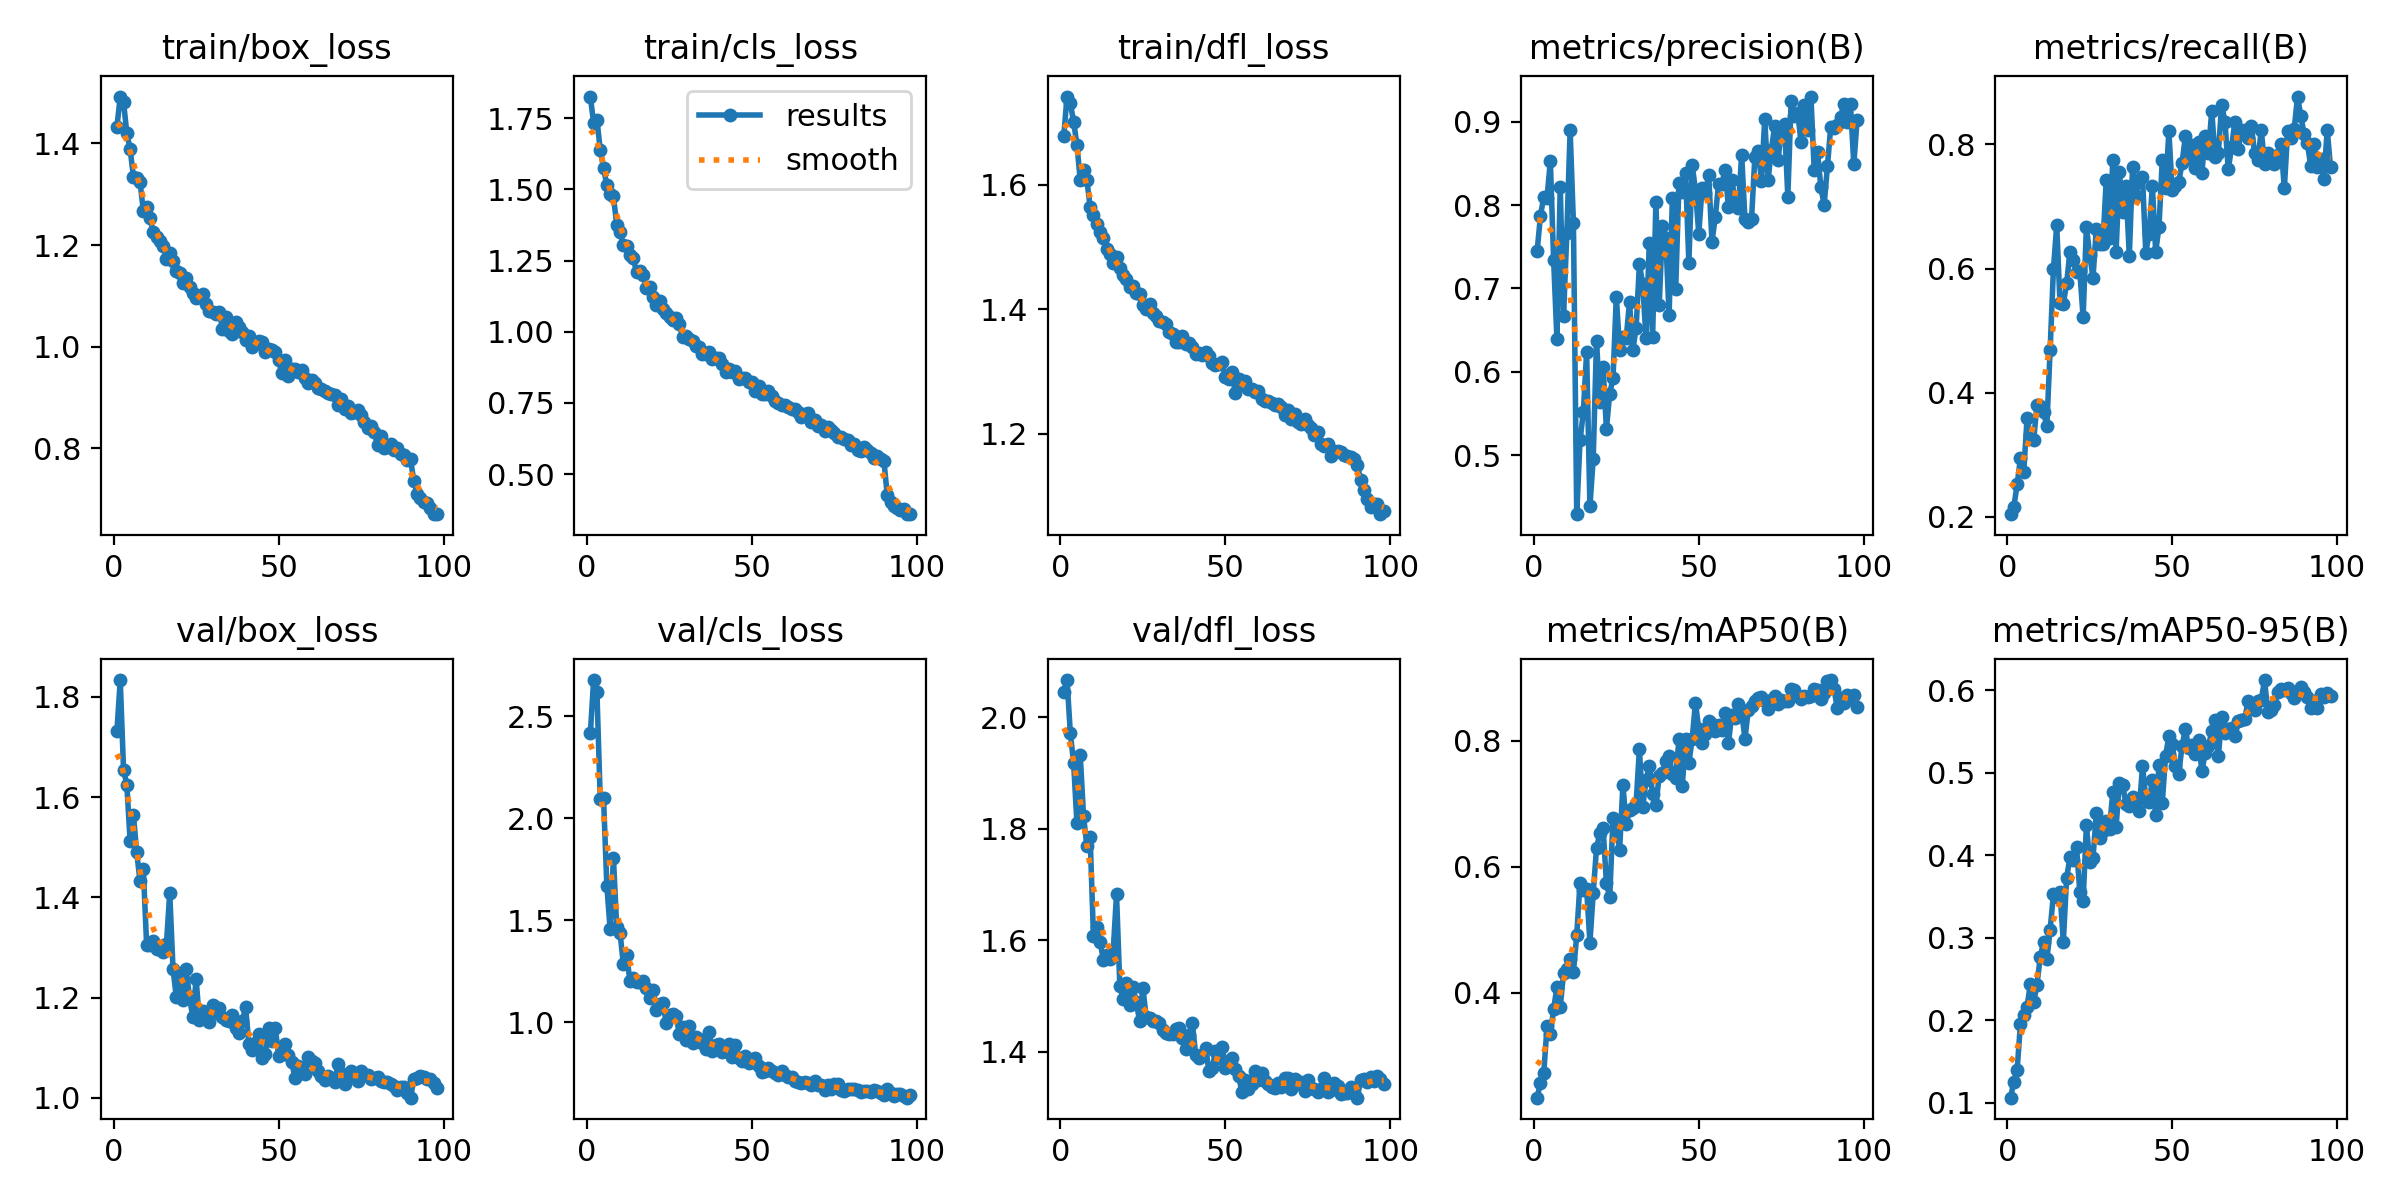

In [ ]:
from IPython.display import display, Image

display(Image(filename=f"{RUN}/results.png"))

In [ ]:
import os
import glob
import random
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

BEST_MODEL = "/content/drive/MyDrive/weapon_detection_project/training/weapon_yolo11s-2/weights/best.pt"
TEST_IMG_DIR = "/content/yolo_dataset/images/test"

if os.path.exists(BEST_MODEL) and os.path.exists(TEST_IMG_DIR):
    eval_model = YOLO(BEST_MODEL)
    test_files = glob.glob(f"{TEST_IMG_DIR}/*.jpg") + glob.glob(f"{TEST_IMG_DIR}/*.png")
    sample_files = random.sample(test_files, min(6, len(test_files)))

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle("YOLO11s Test Set Baseline Predictions", fontsize=16, fontweight="bold")

    for idx, (ax, img_path) in enumerate(zip(axes.flat, sample_files)):
        res = eval_model.predict(img_path, conf=0.4, verbose=False)[0]
        ax.imshow(res.plot()[:, :, ::-1])
        ax.set_title(os.path.basename(img_path), fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


---
## 8. Phase 2: Toy Weapon Fine-Tuning (25 Epochs)
To further sharpen the discrimination between genuine firearms and realistic toy weapons, we fine-tune the model with a specialized toy-dense dataset and a reduced learning rate (`lr0 = 0.0002`).


In [ ]:
import os
import shutil
from glob import glob

SOURCE_DATASET = "/content/drive/MyDrive/weapon_detection_project/yolo_dataset"
TOY_RAW = "/content/new_toy_raw"
NEW_DATASET = "/content/toy_finetune_dataset"

print("========================================")
print("BUILDING FINE-TUNING DATASET")
print("========================================")

# Remove old temporary dataset if it exists
if os.path.exists(NEW_DATASET):
    shutil.rmtree(NEW_DATASET)

# Create directory structure
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(NEW_DATASET, "images", split), exist_ok=True)
    os.makedirs(os.path.join(NEW_DATASET, "labels", split), exist_ok=True)

# Copy original dataset
print("\nCopying original dataset...")

for split in ["train", "val", "test"]:
    src_img = os.path.join(SOURCE_DATASET, "images", split)
    src_lbl = os.path.join(SOURCE_DATASET, "labels", split)

    dst_img = os.path.join(NEW_DATASET, "images", split)
    dst_lbl = os.path.join(NEW_DATASET, "labels", split)

    for file in glob(os.path.join(src_img, "*")):
        if os.path.isfile(file):
            shutil.copy2(file, dst_img)

    for file in glob(os.path.join(src_lbl, "*")):
        if os.path.isfile(file):
            shutil.copy2(file, dst_lbl)

print("Original dataset copied.")

# -------------------------------------------------
# Add new toy dataset
# -------------------------------------------------

print("\nAdding new toy dataset...")

toy_counter = 0
toy_box_count = 0
skipped = 0

valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for split in ["train", "valid", "test"]:
    image_dir = os.path.join(TOY_RAW, split, "images")
    label_dir = os.path.join(TOY_RAW, split, "labels")

    if not os.path.exists(image_dir):
        continue

    for image_path in sorted(glob(os.path.join(image_dir, "*"))):

        if os.path.splitext(image_path)[1].lower() not in valid_ext:
            continue

        base = os.path.splitext(os.path.basename(image_path))[0]
        label_path = os.path.join(label_dir, base + ".txt")

        # Skip missing labels
        if not os.path.exists(label_path):
            skipped += 1
            continue

        # Read annotation
        with open(label_path, "r") as f:
            lines = [line.strip() for line in f if line.strip()]

        # Validate YOLO detection format
        valid_lines = []

        for line in lines:
            parts = line.split()

            if len(parts) != 5:
                continue

            try:
                cls, x, y, w, h = map(float, parts)

                # Source dataset has gun-toy = class 0
                # Our project uses toy_weapon = class 1
                if int(cls) != 0:
                    continue

                if not (0 <= x <= 1 and
                        0 <= y <= 1 and
                        0 < w <= 1 and
                        0 < h <= 1):
                    continue

                valid_lines.append(f"1 {x} {y} {w} {h}")

            except:
                continue

        # Skip invalid/empty annotations
        if not valid_lines:
            skipped += 1
            continue

        new_name = f"NEWTOY_{toy_counter:04d}"

        ext = os.path.splitext(image_path)[1].lower()

        dst_image = os.path.join(
            NEW_DATASET,
            "images",
            "train",
            new_name + ext
        )

        dst_label = os.path.join(
            NEW_DATASET,
            "labels",
            "train",
            new_name + ".txt"
        )

        shutil.copy2(image_path, dst_image)

        with open(dst_label, "w") as f:
            f.write("\n".join(valid_lines) + "\n")

        toy_counter += 1
        toy_box_count += len(valid_lines)

print("\n========================================")
print("DATASET BUILD COMPLETE")
print("========================================")

print("Original dataset + new toy data")
print("New toy images added :", toy_counter)
print("New toy boxes added  :", toy_box_count)
print("Skipped files        :", skipped)
print("Dataset location     :", NEW_DATASET)

BUILDING FINE-TUNING DATASET

Copying original dataset...
Original dataset copied.

Adding new toy dataset...

DATASET BUILD COMPLETE
Original dataset + new toy data
New toy images added : 687
New toy boxes added  : 690
Skipped files        : 80
Dataset location     : /content/toy_finetune_dataset


In [ ]:
import os
from glob import glob
from collections import Counter

DATASET = "/content/toy_finetune_dataset"

print("========================================")
print("FINAL DATASET VERIFICATION")
print("========================================")

for split in ["train", "val", "test"]:

    image_dir = os.path.join(DATASET, "images", split)
    label_dir = os.path.join(DATASET, "labels", split)

    images = [
        f for f in glob(os.path.join(image_dir, "*"))
        if os.path.isfile(f)
    ]

    labels = [
        f for f in glob(os.path.join(label_dir, "*.txt"))
        if os.path.isfile(f)
    ]

    class_counts = Counter()

    for label_file in labels:
        with open(label_file, "r") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) == 5:
                    class_id = parts[0]
                    class_counts[class_id] += 1

    print(f"\n{split.upper()}")
    print("----------------------------------------")
    print("Images :", len(images))
    print("Labels :", len(labels))
    print("real_weapon (class 0):", class_counts["0"])
    print("toy_weapon  (class 1):", class_counts["1"])
    print("Total boxes:", sum(class_counts.values()))

print("\n========================================")
print("DATASET YAML")
print("========================================")

yaml_path = os.path.join(DATASET, "data_finetune.yaml")

with open(yaml_path, "w") as f:
    f.write("""path: /content/toy_finetune_dataset
train: images/train
val: images/val
test: images/test
names:
  0: real_weapon
  1: toy_weapon
""")

print("YAML created:", yaml_path)

with open(yaml_path, "r") as f:
    print("\n" + f.read())

FINAL DATASET VERIFICATION

TRAIN
----------------------------------------
Images : 4072
Labels : 4072
real_weapon (class 0): 2647
toy_weapon  (class 1): 907
Total boxes: 3554

VAL
----------------------------------------
Images : 725
Labels : 725
real_weapon (class 0): 594
toy_weapon  (class 1): 31
Total boxes: 625

TEST
----------------------------------------
Images : 727
Labels : 727
real_weapon (class 0): 559
toy_weapon  (class 1): 52
Total boxes: 611

DATASET YAML
YAML created: /content/toy_finetune_dataset/data_finetune.yaml

path: /content/toy_finetune_dataset
train: images/train
val: images/val
test: images/test
names:
  0: real_weapon
  1: toy_weapon



In [ ]:
from ultralytics import YOLO

DATA_YAML = "/content/toy_finetune_dataset/data_finetune.yaml"

results = model.train(
    data=DATA_YAML,

    # Fine-tuning duration
    epochs=25,

    # Image / batch
    imgsz=640,
    batch=16,

    # Optimizer / low LR for fine-tuning
    optimizer="AdamW",
    lr0=0.0002,
    lrf=0.01,
    weight_decay=0.0005,

    # Early stopping
    patience=8,

    # Augmentation
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=5,
    translate=0.1,
    scale=0.5,
    shear=0,
    perspective=0.0005,
    flipud=0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.05,
    copy_paste=0,

    # Save to Google Drive
    project="/content/drive/MyDrive/weapon_detection_project/training",
    name="weapon_yolo11s_toy_finetune",
    exist_ok=True,

    verbose=True
)

New https://pypi.org/project/ultralytics/8.4.173 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/toy_finetune_dataset/data_finetune.yaml, degrees=5, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.0002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=/cont

In [ ]:
from ultralytics import YOLO
import os
import torch

BEST_FINETUNED = (
    "/content/drive/MyDrive/weapon_detection_project/"
    "training/weapon_yolo11s_toy_finetune/weights/best.pt"
)

print("========================================")
print("FINE-TUNED MODEL CHECK")
print("========================================")

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\nBest model exists:", os.path.exists(BEST_FINETUNED))

if os.path.exists(BEST_FINETUNED):
    print(
        "Model size:",
        round(os.path.getsize(BEST_FINETUNED) / (1024 * 1024), 2),
        "MB"
    )

    test_model = YOLO(BEST_FINETUNED)

    print("Model loaded successfully.")
    print("Classes:", test_model.names)
    print("Path:", BEST_FINETUNED)
else:
    print("ERROR: Fine-tuned best.pt was not found.")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
FINE-TUNED MODEL CHECK
CUDA available: False

Best model exists: True
Model size: 18.27 MB
Model loaded successfully.
Classes: {0: 'real_weapon', 1: 'toy_weapon'}
Path: /content/drive/MyDrive/weapon_detection_project/training/weapon_yolo11s_toy_finetune/weights/best.pt


---
## 9. Comprehensive Model Evaluation & Metric Comparison
Evaluate the final fine-tuned model on the unseen test split and display confusion matrices, precision-recall curves, and class metrics.


In [ ]:
import os
import glob
import yaml
from ultralytics import YOLO

# ============================================================
# 1. PROJECT PATH
# ============================================================

PROJECT = "/content/drive/MyDrive/weapon_detection_project"

print("=" * 70)
print("YOLO WEAPON DETECTION — COMPLETE MODEL EVALUATION")
print("=" * 70)

# ============================================================
# 2. FIND FINE-TUNED BEST MODEL
# ============================================================

model_candidates = glob.glob(
    PROJECT + "/**/weapon_yolo11s_toy_finetune/weights/best.pt",
    recursive=True
)

if not model_candidates:
    model_candidates = glob.glob(
        PROJECT + "/**/weights/best.pt",
        recursive=True
    )

if not model_candidates:
    raise FileNotFoundError("Could not find best.pt inside the project.")

BEST_MODEL = model_candidates[0]

print("\nBEST MODEL:")
print(BEST_MODEL)

# ============================================================
# 3. FIND FINE-TUNING DATASET
# ============================================================

dataset_candidates = []

for root, dirs, files in os.walk(PROJECT):
    if (
        os.path.isdir(os.path.join(root, "images")) and
        os.path.isdir(os.path.join(root, "labels"))
    ):
        dataset_candidates.append(root)

print("\nDATASET CANDIDATES:")

for d in dataset_candidates:
    print(" ", d)

# Prefer toy_finetune_dataset if it was saved on Drive
preferred = [
    d for d in dataset_candidates
    if "toy_finetune" in d.lower()
]

if preferred:
    DATASET = preferred[0]
else:
    # Look for a dataset containing test images + labels
    valid_candidates = []

    for d in dataset_candidates:
        if (
            os.path.isdir(os.path.join(d, "images", "test")) and
            os.path.isdir(os.path.join(d, "labels", "test"))
        ):
            valid_candidates.append(d)

    if len(valid_candidates) == 1:
        DATASET = valid_candidates[0]
    elif len(valid_candidates) > 1:
        print("\nMultiple test datasets found.")
        print("Please select the correct one manually:")
        for i, d in enumerate(valid_candidates):
            print(i, d)
        raise RuntimeError("Multiple possible datasets found.")
    else:
        raise FileNotFoundError(
            "Could not find a saved dataset containing images/test and labels/test."
        )

print("\nSELECTED DATASET:")
print(DATASET)

# ============================================================
# 4. CREATE A LOCAL YAML FOR THE SAVED DATASET
# ============================================================

EVAL_YAML = "/content/evaluation_data.yaml"

yaml_data = {
    "path": DATASET,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {
        0: "real_weapon",
        1: "toy_weapon"
    }
}

with open(EVAL_YAML, "w") as f:
    yaml.safe_dump(yaml_data, f, sort_keys=False)

print("\nEvaluation YAML:")
print(EVAL_YAML)

# ============================================================
# 5. LOAD MODEL
# ============================================================

model = YOLO(BEST_MODEL)

print("\nMODEL CLASSES:")
print(model.names)

# ============================================================
# 6. COMPLETE TEST EVALUATION
# ============================================================

print("\n" + "=" * 70)
print("RUNNING TEST EVALUATION")
print("=" * 70)

metrics = model.val(
    data=EVAL_YAML,
    split="test",
    imgsz=640,
    conf=0.50,
    iou=0.50,
    plots=True,
    save_json=True,
    verbose=True
)

# ============================================================
# 7. OVERALL METRICS
# ============================================================

print("\n" + "=" * 70)
print("OVERALL RESULTS")
print("=" * 70)

precision = metrics.box.mp
recall = metrics.box.mr
map50 = metrics.box.map50
map5095 = metrics.box.map

# Calculate overall F1
if precision + recall > 0:
    f1 = 2 * precision * recall / (precision + recall)
else:
    f1 = 0.0

print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"F1-score        : {f1:.4f}")
print(f"mAP50           : {map50:.4f}")
print(f"mAP50-95        : {map5095:.4f}")

# ============================================================
# 8. PER-CLASS RESULTS
# ============================================================

print("\n" + "=" * 70)
print("PER-CLASS RESULTS")
print("=" * 70)

for i, class_name in model.names.items():

    p = metrics.box.p[i]
    r = metrics.box.r[i]
    ap50 = metrics.box.ap50[i]
    ap = metrics.box.ap[i]

    if p + r > 0:
        class_f1 = 2 * p * r / (p + r)
    else:
        class_f1 = 0.0

    print(f"\n{class_name}")
    print("-" * 40)
    print(f"Precision       : {p:.4f}")
    print(f"Recall          : {r:.4f}")
    print(f"F1-score        : {class_f1:.4f}")
    print(f"mAP50           : {ap50:.4f}")
    print(f"mAP50-95        : {ap:.4f}")

# ============================================================
# 9. CONFUSION MATRIX / PLOTS LOCATION
# ============================================================

print("\n" + "=" * 70)
print("GENERATED EVALUATION FILES")
print("=" * 70)

save_dir = str(metrics.save_dir)

print("\nEvaluation directory:")
print(save_dir)

plot_files = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
    "results.png"
]

for filename in plot_files:
    path = os.path.join(save_dir, filename)

    if os.path.exists(path):
        print(f"\n{filename}")
        print(path)

# ============================================================
# 10. TEST DATASET SIZE
# ============================================================

test_images = glob.glob(
    os.path.join(DATASET, "images", "test", "*")
)

test_labels = glob.glob(
    os.path.join(DATASET, "labels", "test", "*.txt")
)

print("\n" + "=" * 70)
print("TEST DATASET")
print("=" * 70)

print("Test images :", len(test_images))
print("Test labels :", len(test_labels))

# ============================================================
# 11. RUN PREDICTIONS AND SAVE VISUAL RESULTS
# ============================================================

PREDICT_DIR = os.path.join(
    PROJECT,
    "evaluation",
    "test_predictions"
)

print("\n" + "=" * 70)
print("CREATING TEST PREDICTION IMAGES")
print("=" * 70)

model.predict(
    source=os.path.join(DATASET, "images", "test"),
    imgsz=640,
    conf=0.50,
    save=True,
    save_txt=True,
    save_conf=True,
    project=PREDICT_DIR,
    name="predictions",
    exist_ok=True,
    verbose=False
)

print("\nPrediction images saved to:")
print(
    os.path.join(
        PREDICT_DIR,
        "predictions"
    )
)

print("\n" + "=" * 70)
print("EVALUATION COMPLETE")
print("=" * 70)

YOLO WEAPON DETECTION — COMPLETE MODEL EVALUATION

BEST MODEL:
/content/drive/MyDrive/weapon_detection_project/training/weapon_yolo11s_toy_finetune/weights/best.pt

DATASET CANDIDATES:
  /content/drive/MyDrive/weapon_detection_project/toy_dataset_raw/test
  /content/drive/MyDrive/weapon_detection_project/toy_dataset_raw/train
  /content/drive/MyDrive/weapon_detection_project/toy_dataset_raw/valid
  /content/drive/MyDrive/weapon_detection_project/hard_negatives/toy_weapon
  /content/drive/MyDrive/weapon_detection_project/hard_negatives/representation
  /content/drive/MyDrive/weapon_detection_project/hard_negatives/toy_weapon_subset
  /content/drive/MyDrive/weapon_detection_project/yolo_dataset
  /content/drive/MyDrive/weapon_detection_project/final_dataset

SELECTED DATASET:
/content/drive/MyDrive/weapon_detection_project/yolo_dataset

Evaluation YAML:
/content/evaluation_data.yaml

MODEL CLASSES:
{0: 'real_weapon', 1: 'toy_weapon'}

RUNNING TEST EVALUATION
Ultralytics 8.4.172 🚀 Python-

CONFUSION MATRICES

confusion_matrix.png


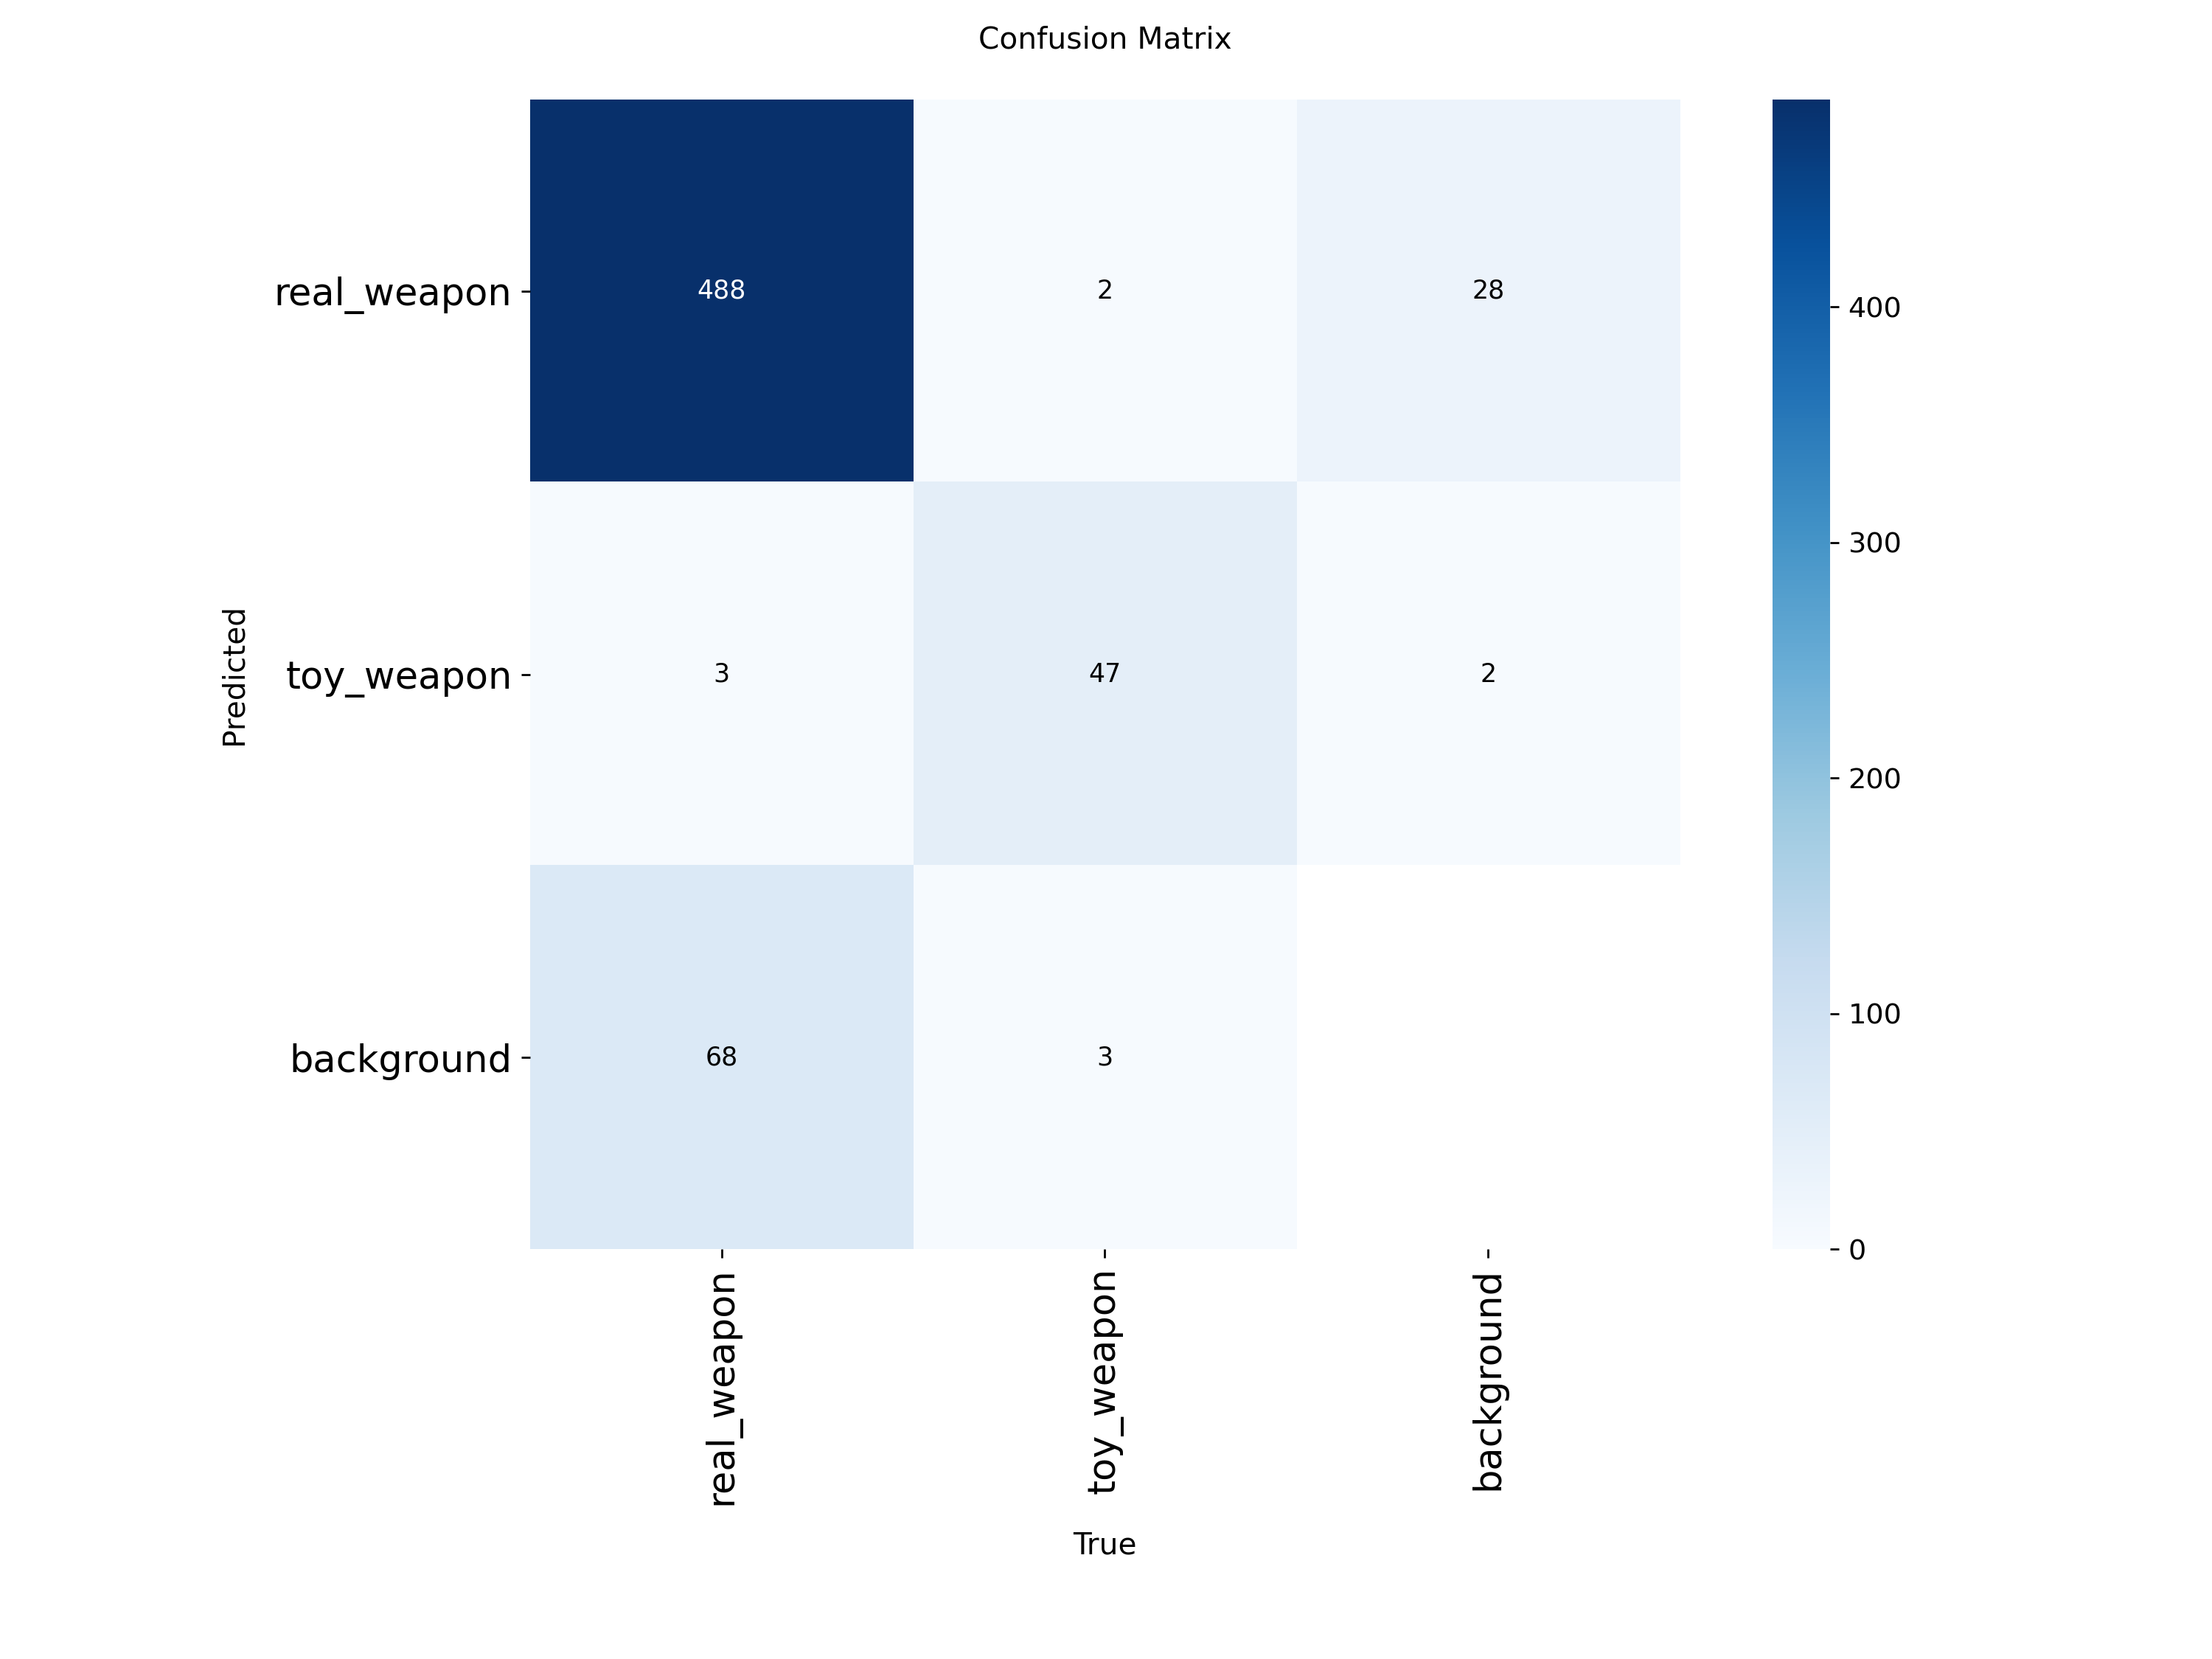


confusion_matrix_normalized.png


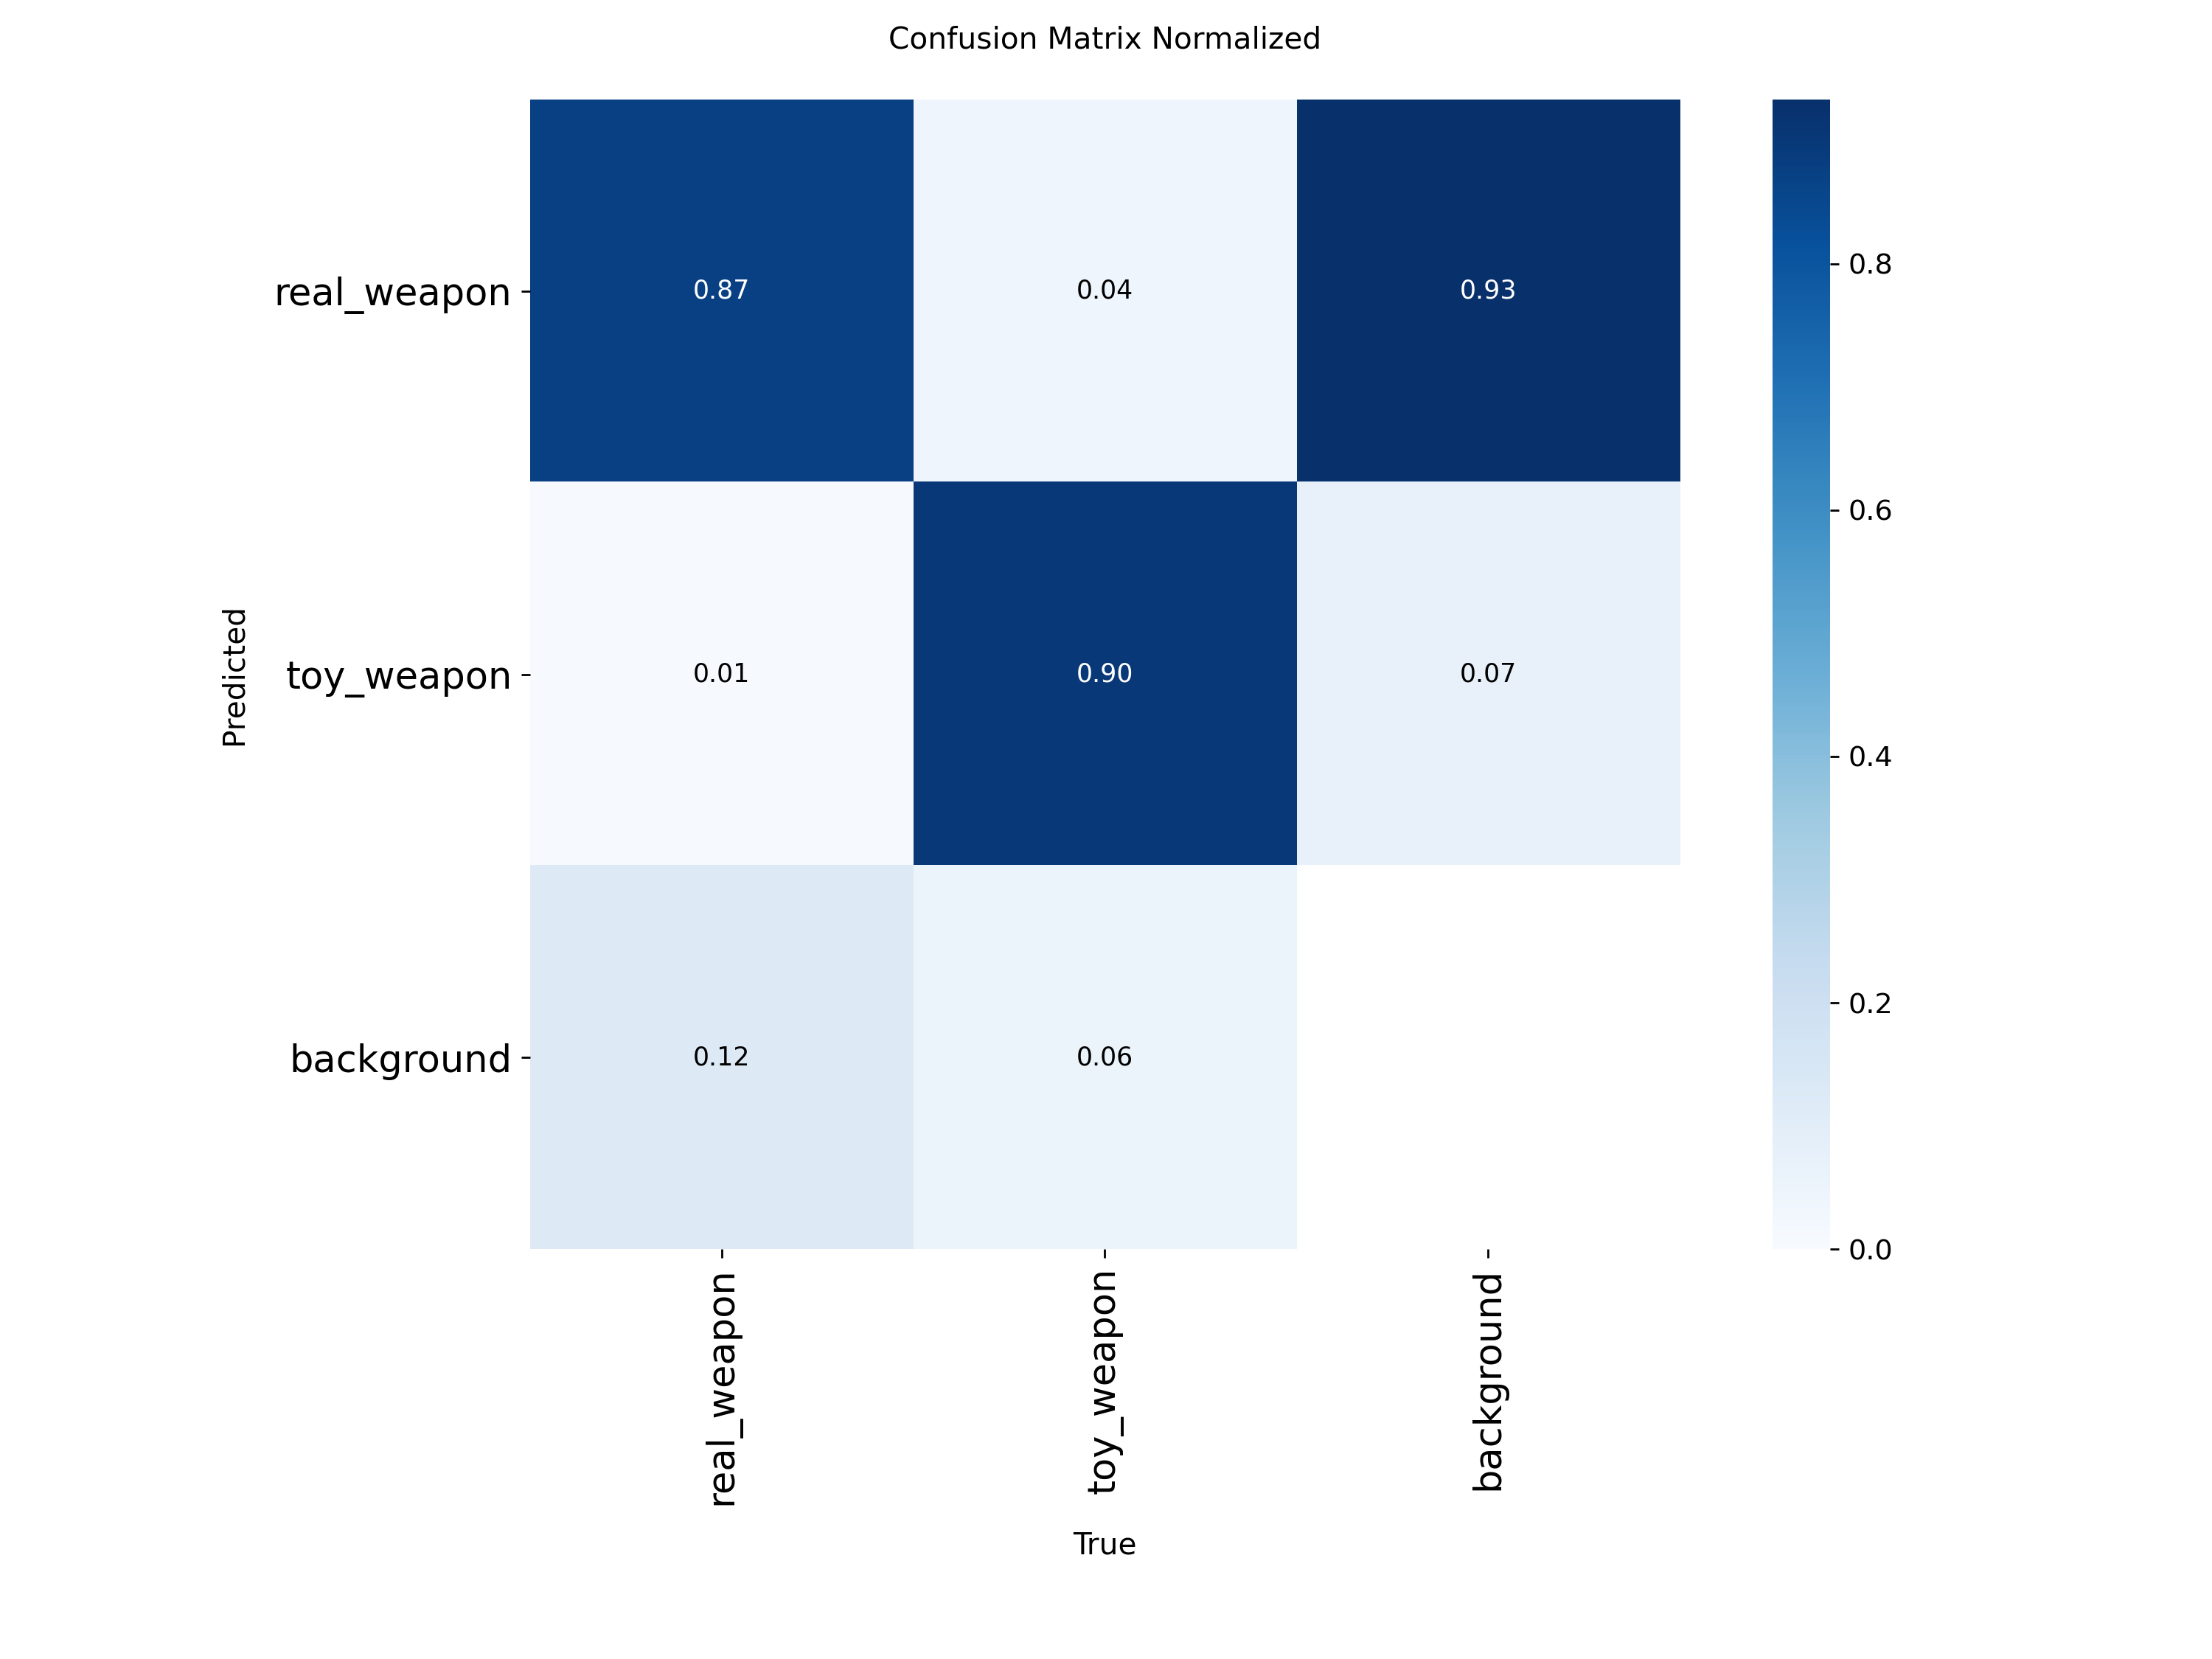


PR_curve.png — not generated

F1_curve.png — not generated

P_curve.png — not generated

R_curve.png — not generated


In [ ]:
from IPython.display import display, Image
import os

VAL_DIR = "/content/runs/detect/val-2"

print("========================================")
print("CONFUSION MATRICES")
print("========================================")

files = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
]

for filename in files:
    path = os.path.join(VAL_DIR, filename)

    if os.path.exists(path):
        print(f"\n{filename}")
        display(Image(filename=path))
    else:
        print(f"\n{filename} — not generated")

---
## 10. Live Inference Demo & Model Export
Inference functions for real-time video feeds, single-image detection, and exporting the trained model to ONNX format for web/mobile deployment.


In [ ]:
from ultralytics import YOLO
import os

MODEL_PATH = "/content/drive/MyDrive/weapon_detection_project/training/weapon_yolo11s-2/weights/best.pt"
if not os.path.exists(MODEL_PATH):
    MODEL_PATH = "yolo11s.pt"

model = YOLO(MODEL_PATH)

def detect_weapon(image_path, conf_threshold=0.45):
    """Run weapon detection on a single image and print alerts."""
    results = model.predict(image_path, conf=conf_threshold, verbose=False)
    for r in results:
        boxes = r.boxes
        if len(boxes) == 0:
            print("✅ Area Clear: No weapons detected.")
            continue
        for box in boxes:
            cls_id = int(box.cls[0])
            cls_name = model.names[cls_id]
            conf = float(box.conf[0])
            threat = "🔴 HIGH THREAT" if cls_name == "real_weapon" else "🟡 LOW THREAT (TOY)"
            print(f"[{threat}] Detected {cls_name} ({conf:.1%}) at coords: {box.xyxy[0].tolist()}")

# Export model to ONNX for lightweight edge / web deployment
print("Exporting model to ONNX...")
onnx_path = model.export(format="onnx", imgsz=640, dynamic=False, simplify=True)
print(f"Export completed: {onnx_path}")
